# Semana 10 – Red Neuronal Siamesa

En este notebook se implementa una red neuronal siamesa para comparar pares de imágenes y determinar si pertenecen a la misma clase.

Se utiliza el dataset MNIST como aproximación al problema de reconocimiento de similitud.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
def crear_pares(x, y):

    pares = []
    etiquetas = []

    num_clases = 10

    indices = [np.where(y == i)[0] for i in range(num_clases)]

    for i in range(len(x)):

        # positivo (misma clase)
        clase = y[i]
        idx = np.random.choice(indices[clase])

        pares.append([x[i], x[idx]])
        etiquetas.append(1)

        # negativo (clase diferente)
        clase_neg = np.random.randint(0, num_clases)
        while clase_neg == clase:
            clase_neg = np.random.randint(0, num_clases)

        idx_neg = np.random.choice(indices[clase_neg])

        pares.append([x[i], x[idx_neg]])
        etiquetas.append(0)

    return np.array(pares), np.array(etiquetas)

In [4]:
pares_train, etiquetas_train = crear_pares(x_train[:10000], y_train[:10000])
pares_test, etiquetas_test = crear_pares(x_test[:2000], y_test[:2000])

print(pares_train.shape)

(20000, 2, 28, 28)


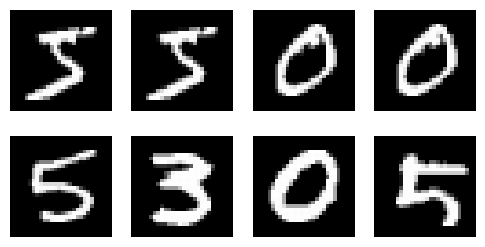

In [5]:
plt.figure(figsize=(6,3))

for i in range(4):
    plt.subplot(2,4,i+1)
    plt.imshow(pares_train[i][0], cmap='gray')
    plt.axis('off')

    plt.subplot(2,4,i+5)
    plt.imshow(pares_train[i][1], cmap='gray')
    plt.axis('off')

plt.show()

In [6]:
def crear_red_base():

    input = layers.Input(shape=(28,28))

    x = layers.Flatten()(input)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    return Model(input, x)

In [9]:
input_a = layers.Input(shape=(28,28))
input_b = layers.Input(shape=(28,28))

red_base = crear_red_base()

emb_a = red_base(input_a)
emb_b = red_base(input_b)

# distancia absoluta
distancia = layers.Lambda(lambda x: tf.abs(x))(emb_a - emb_b)

salida = layers.Dense(1, activation='sigmoid')(distancia)

modelo = Model([input_a, input_b], salida)

modelo.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 64)        │    108,736 │ input_layer_3[0]… │
│ (Functional)        │                   │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 64)        │          0 │ functional_1[0][… │
│ (Subtract)          │                   │            │ functional_1[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ subtract_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         65 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
hist = modelo.fit(
    [pares_train[:,0], pares_train[:,1]],
    etiquetas_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7868 - loss: 0.4564 - val_accuracy: 0.8372 - val_loss: 0.3801
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8912 - loss: 0.2805 - val_accuracy: 0.8670 - val_loss: 0.3177
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9283 - loss: 0.1987 - val_accuracy: 0.8935 - val_loss: 0.2671
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9521 - loss: 0.1412 - val_accuracy: 0.9028 - val_loss: 0.2501
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9680 - loss: 0.1003 - val_accuracy: 0.9072 - val_loss: 0.2430


In [11]:
loss, acc = modelo.evaluate(
    [pares_test[:,0], pares_test[:,1]],
    etiquetas_test
)

print("Accuracy:", acc)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8917 - loss: 0.2898
Accuracy: 0.8917499780654907


In [12]:
pred = modelo.predict([pares_test[:10,0], pares_test[:10,1]])

for i in range(5):
    print("Predicción:", pred[i][0], "Real:", etiquetas_test[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicción: 0.97359675 Real: 1
Predicción: 0.06880385 Real: 0
Predicción: 0.99964535 Real: 1
Predicción: 7.79938e-05 Real: 0
Predicción: 0.9994565 Real: 1


## Explicación

Una red siamesa es un tipo de red neuronal que recibe dos entradas y aprende a compararlas.

Cada entrada pasa por la misma red (comparten pesos), generando representaciones internas.

Luego se calcula una distancia entre esas representaciones para determinar si son similares o diferentes.

En este caso, el modelo aprende a identificar si dos imágenes corresponden al mismo número o a números distintos.

## Análisis

El modelo aprende a diferenciar pares positivos y negativos mediante la distancia entre representaciones.

Se observa que cuando las imágenes pertenecen a la misma clase, la predicción tiende a valores cercanos a 1.

Cuando pertenecen a clases diferentes, la salida se aproxima a 0.

Esto indica que la red logra capturar características relevantes para comparar imágenes.

## Conclusiones

1. Las redes siamesas permiten comparar dos entradas en lugar de clasificar directamente.
2. Son útiles en problemas de reconocimiento facial y verificación de identidad.
3. El modelo aprende una representación interna que permite medir similitud.
4. Su desempeño depende de la calidad de los pares positivos y negativos.